## Getting new data from the original 

[0.5 0.2 1.  0.3]


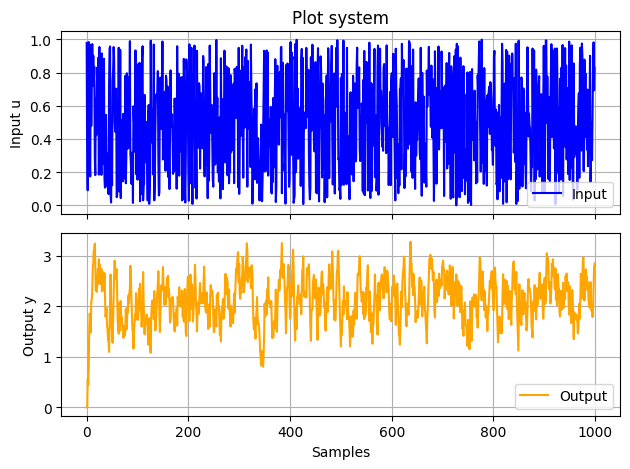

In [18]:
import matplotlib.pyplot as plt
import numpy as np

N = 1000

a1 = 0.5
a2 = 0.2
b1 = 1
b2 = 0.3

# Create a random number generator
# rng = np.random.default_rng()

# Generate N random floats between 0.0 (inclusive) and 1.0 (exclusive)
# u = rng.random(size=N)
u = np.random.uniform(size=N)
#e = np.random.normal(0, 0.01, size=N)
y = np.zeros(N)

for k in range(2, N):
    y[k] = a1 * y[k - 1] + a2 * y[k - 2] + b1 * u[k - 1] + b2 * u[k - 2] #+ e[k]


# Método dos mínimos quadrados
# theta_est = (psi_trans * psi)ˆ-1*psi_trans*y

psi = np.zeros((N - 2, 4))
for k in range(2, N):
    psi[k - 2, 0] = y[k - 1]
    psi[k - 2, 1] = y[k - 2]
    psi[k - 2, 2] = u[k - 1]
    psi[k - 2, 3] = u[k - 2]

psi_trans = psi.T
theta_est = np.linalg.inv(psi_trans @ psi) @ psi_trans @ y[2:]

print(theta_est)


# plt.plot(y)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(u, label="Input", color="blue", linestyle="-")
ax1.set_ylabel("Input u")
ax1.set_title("Plot system")
ax1.legend()
ax1.grid(True)

ax2.plot(y, label="Output", color="orange", linestyle="-")
ax2.set_ylabel("Output y")
ax2.set_xlabel("Samples")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# print(len(u))
# print(len(y))


## Aplicação Método dos mínimos quadrados extendido

In [ ]:
#print(psi)
new_psi = (psi[:,[0,2]])

for j in range(2, N):
    new_psi[j - 2, 0] = y[j - 1]
    new_psi[j - 2, 1] = u[j - 1]

psi_trans = new_psi.T
new_theta = np.linalg.inv(psi_trans @ new_psi) @ psi_trans @ y[2:]

print(new_theta)


[0.76990244 0.99812786]


In [38]:
# new psi3

# Método dos mínimos quadrados
# theta_est = (psi_trans * psi)ˆ-1*psi_trans*y

# psi3 = np.column_stack([
#     psi[1:, :],          # existing 4 columns (y[k-1], y[k-2], u[k-1], u[k-2]), trimmed
#     y[0:N-3],            # new column: y[k-3]
#     u[0:N-3]             # new column: u[k-3]
# ])

psi3 = np.zeros((N - 3, 6))

for k in range(3, N):
    psi3[k - 3, 0] = y[k - 1]
    psi3[k - 3, 1] = y[k - 2]
    psi3[k - 3, 2] = y[k - 3]
    psi3[k - 3, 3] = u[k - 1]
    psi3[k - 3, 4] = u[k - 2]
    psi3[k - 3, 5] = u[k - 3]


psi_trans2 = psi3.T
new_theta2 = np.linalg.inv(psi_trans2 @ psi3) @ psi_trans2 @ y[3:]

print(new_theta2)

[ 0.76858095 -0.28467681 -0.09102107  1.00043235 -0.25267281 -0.15480407]
